
# LSTM Baseline — Incident Classification with Early Stopping

This notebook trains and evaluates an LSTM for the fixed three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

It uses the same frozen files as the tree-based baselines:

1. `canonical_dataset_revised.csv`
2. `grouped_random_split_manifest_revised.csv`
3. `spatial_split_manifest_revised.csv`

The input is the 7-hour traffic sequence:

\[
[t-3,\ t-2,\ t-1,\ t0,\ t+1,\ t+2,\ t+3]
\]

Early stopping monitors validation loss and restores the best model weights.  
Model selection remains based on validation Macro-F1, while the test set is used only once for final evaluation.


In [1]:

# Run only if TensorFlow is not installed:
# !pip install -U tensorflow

from pathlib import Path
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_INT = {label: i for i, label in enumerate(CLASS_ORDER)}
INT_TO_CLASS = {i: label for label, i in CLASS_TO_INT.items()}

DATA_DIR = Path(".")

CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")

OUTPUT_DIR = DATA_DIR / "lstm_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR."
        )

print("Output directory:", OUTPUT_DIR.resolve())


TensorFlow version: 2.19.0
Output directory: /Users/andishahifahmuthahharah/Downloads/lstm_outputs


## 1. Load and validate the fixed data

In [2]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

assert canonical["event_sample_id"].is_unique
assert grouped_manifest["event_sample_id"].is_unique
assert spatial_manifest["event_sample_id"].is_unique

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"])
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"])
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

print("Integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179


Integrity checks passed.


## 2. Prepare the 7-hour LSTM sequence

In [3]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

def merge_split(canonical_df: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df)
    assert (
        merged["target_class"] == merged["target_class_manifest"]
    ).all()

    return merged.drop(columns="target_class_manifest")

def encode_target(y: pd.Series) -> np.ndarray:
    encoded = y.map(CLASS_TO_INT)
    if encoded.isna().any():
        raise ValueError("Unknown target class found.")
    return encoded.astype(int).to_numpy()

def decode_target(y_int) -> np.ndarray:
    return np.array([INT_TO_CLASS[int(v)] for v in y_int])

def prepare_sequence_data(data: pd.DataFrame):
    flow = data[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    # Two channels per time step:
    # 1) log-transformed traffic level
    # 2) first difference; the first position is padded with zero
    log_flow = np.log1p(flow)
    diff = np.diff(log_flow, axis=1, prepend=log_flow[:, [0]])

    X = np.stack([log_flow, diff], axis=-1).astype(np.float32)
    y = encode_target(data["target_class"])

    return X, y

def metric_row(y_true_label, y_pred_label):
    return {
        "accuracy": accuracy_score(y_true_label, y_pred_label),
        "balanced_accuracy": balanced_accuracy_score(y_true_label, y_pred_label),
        "macro_f1": f1_score(
            y_true_label, y_pred_label, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true_label, y_pred_label, average="weighted", zero_division=0
        ),
    }



## 3. LSTM configurations

A compact set of regularised configurations is evaluated. Each model uses:

- masking-free fixed-length sequences;
- one LSTM layer;
- dropout and recurrent dropout;
- dense classification head;
- class weights computed from the training set;
- early stopping on validation loss;
- learning-rate reduction when validation loss plateaus.

The maximum epoch count is deliberately high because early stopping determines the effective training duration.


In [4]:

MODEL_CONFIGS = [
    {
        "lstm_units": 32,
        "dense_units": 16,
        "dropout": 0.30,
        "recurrent_dropout": 0.10,
        "learning_rate": 1e-3,
        "l2_strength": 1e-4,
    },
    {
        "lstm_units": 64,
        "dense_units": 32,
        "dropout": 0.40,
        "recurrent_dropout": 0.10,
        "learning_rate": 1e-3,
        "l2_strength": 1e-4,
    },
    {
        "lstm_units": 32,
        "dense_units": 16,
        "dropout": 0.50,
        "recurrent_dropout": 0.20,
        "learning_rate": 5e-4,
        "l2_strength": 1e-3,
    },
]

MAX_EPOCHS = 300
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 25
REDUCE_LR_PATIENCE = 10

print("Model configurations:", len(MODEL_CONFIGS))


Model configurations: 3


In [5]:

def build_lstm_model(input_shape, config):
    regularizer = tf.keras.regularizers.l2(config["l2_strength"])

    inputs = tf.keras.Input(shape=input_shape, name="traffic_sequence")

    x = tf.keras.layers.LSTM(
        config["lstm_units"],
        dropout=config["dropout"],
        recurrent_dropout=config["recurrent_dropout"],
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
        name="lstm",
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(
        config["dense_units"],
        activation="relu",
        kernel_regularizer=regularizer,
        name="dense_hidden",
    )(x)

    x = tf.keras.layers.Dropout(config["dropout"])(x)

    outputs = tf.keras.layers.Dense(
        len(CLASS_ORDER),
        activation="softmax",
        name="class_output",
    )(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=config["learning_rate"],
        clipnorm=1.0,
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


## 4. Training, early stopping, and evaluation

In [6]:

def run_lstm_experiment(split_name: str, manifest: pd.DataFrame):
    tf.keras.backend.clear_session()

    data = merge_split(canonical, manifest)
    X, y = prepare_sequence_data(data)
    y_label = data["target_class"].astype(str)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train_raw = X[masks["train"]]
    X_val_raw = X[masks["validation"]]
    X_test_raw = X[masks["test"]]

    y_train = y[masks["train"]]
    y_val = y[masks["validation"]]
    y_test = y[masks["test"]]

    y_train_label = y_label.loc[masks["train"]]
    y_val_label = y_label.loc[masks["validation"]]
    y_test_label = y_label.loc[masks["test"]]

    # Standardise each channel using training data only.
    scaler = StandardScaler()
    train_2d = X_train_raw.reshape(-1, X_train_raw.shape[-1])
    scaler.fit(train_2d)

    def scale_3d(arr):
        shape = arr.shape
        scaled = scaler.transform(arr.reshape(-1, shape[-1]))
        return scaled.reshape(shape).astype(np.float32)

    X_train = scale_3d(X_train_raw)
    X_val = scale_3d(X_val_raw)
    X_test = scale_3d(X_test_raw)

    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(CLASS_ORDER)),
        y=y_train,
    )
    class_weight = {
        i: float(w) for i, w in enumerate(class_weights_values)
    }

    print(f"\n=== {split_name} ===")
    print("Train / validation / test:", len(y_train), len(y_val), len(y_test))
    print("Class weights:", class_weight)

    split_counts = (
        data.groupby(["split", "target_class"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=["train", "validation", "test"],
            columns=CLASS_ORDER,
            fill_value=0,
        )
    )
    display(split_counts)

    search_rows = []
    trained_models = []
    histories = []

    for i, config in enumerate(MODEL_CONFIGS, start=1):
        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_STATE + i)

        model = build_lstm_model(
            input_shape=X_train.shape[1:],
            config=config,
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=True,
                verbose=0,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=REDUCE_LR_PATIENCE,
                min_lr=1e-6,
                verbose=0,
            ),
            tf.keras.callbacks.TerminateOnNaN(),
        ]

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
            shuffle=True,
        )

        val_prob = model.predict(X_val, verbose=0)
        val_pred = np.argmax(val_prob, axis=1)
        val_pred_label = decode_target(val_pred)

        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        best_val_loss = float(np.min(history.history["val_loss"]))

        row = {
            **config,
            "epochs_trained": len(history.history["loss"]),
            "best_epoch": best_epoch,
            "best_validation_loss": best_val_loss,
            **metric_row(y_val_label, val_pred_label),
        }

        search_rows.append(row)
        trained_models.append(model)
        histories.append(history.history)

        print(
            f"{i:02d}/{len(MODEL_CONFIGS)} | "
            f"epochs={row['epochs_trained']:3d} | "
            f"best_epoch={best_epoch:3d} | "
            f"val_macro_f1={row['macro_f1']:.4f} | "
            f"val_loss={best_val_loss:.4f}"
        )

    search_df = pd.DataFrame(search_rows)

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "best_validation_loss"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = trained_models[best_idx]
    best_history = histories[best_idx]
    best_config = MODEL_CONFIGS[best_idx]

    print("\nBest validation configuration:")
    print(best_config)
    display(ranking)

    partition_results = []
    prediction_frames = []

    for part, X_part, y_part, y_part_label in [
        ("train", X_train, y_train, y_train_label),
        ("validation", X_val, y_val, y_val_label),
        ("test", X_test, y_test, y_test_label),
    ]:
        prob = best_model.predict(X_part, verbose=0)
        pred_int = np.argmax(prob, axis=1)
        pred_label = decode_target(pred_int)

        partition_results.append({
            "split_scheme": split_name,
            "partition": part,
            "best_epoch": int(search_df.loc[best_idx, "best_epoch"]),
            **metric_row(y_part_label, pred_label),
        })

        ids = data.loc[masks[part], "event_sample_id"].to_numpy()

        frame = pd.DataFrame({
            "event_sample_id": ids,
            "split_scheme": split_name,
            "partition": part,
            "y_true": y_part_label.to_numpy(),
            "y_pred": pred_label,
        })

        for class_idx, class_name in enumerate(CLASS_ORDER):
            frame[f"prob_{class_name}"] = prob[:, class_idx]

        prediction_frames.append(frame)

    results_df = pd.DataFrame(partition_results)
    prediction_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = prediction_df.loc[
        prediction_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    print("\nOverall metrics:")
    display(results_df)

    print("\nTest classification report:")
    report_df = pd.DataFrame(
        classification_report(
            y_test_label,
            test_pred,
            labels=CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T
    display(report_df)

    safe_name = split_name.lower().replace("-", "_").replace(" ", "_")

    search_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_configuration_search.csv",
        index=False,
    )
    results_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_metrics.csv",
        index=False,
    )
    prediction_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_predictions.csv",
        index=False,
    )
    report_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_test_classification_report.csv"
    )

    best_metadata = {
        **best_config,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "epochs_trained": int(search_df.loc[best_idx, "epochs_trained"]),
        "best_epoch": int(search_df.loc[best_idx, "best_epoch"]),
        "best_validation_loss": float(
            search_df.loc[best_idx, "best_validation_loss"]
        ),
    }

    with open(OUTPUT_DIR / f"{safe_name}_best_config.json", "w") as f:
        json.dump(best_metadata, f, indent=2)

    best_model.save(OUTPUT_DIR / f"{safe_name}_lstm_model.keras")

    np.savez(
        OUTPUT_DIR / f"{safe_name}_scaler.npz",
        mean=scaler.mean_,
        scale=scaler.scale_,
    )

    history_df = pd.DataFrame(best_history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df.to_csv(
        OUTPUT_DIR / f"{safe_name}_training_history.csv",
        index=False,
    )

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df["epoch"], history_df["loss"], label="Training loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    ax.axvline(
        best_metadata["best_epoch"],
        linestyle="--",
        label=f"Best epoch = {best_metadata['best_epoch']}",
    )
    ax.set_title(f"LSTM — {split_name} early stopping")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_early_stopping_curve.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Accuracy curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_df["epoch"], history_df["accuracy"], label="Training accuracy")
    ax.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
    ax.axvline(
        best_metadata["best_epoch"],
        linestyle="--",
        label=f"Best epoch = {best_metadata['best_epoch']}",
    )
    ax.set_title(f"LSTM — {split_name} accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_accuracy_curve.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_label,
        test_pred,
        labels=CLASS_ORDER,
        display_labels=CLASS_ORDER,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"LSTM — {split_name} test confusion matrix")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{safe_name}_confusion_matrix.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    return {
        "model": best_model,
        "best_config": best_metadata,
        "metrics": results_df,
        "report": report_df,
        "predictions": prediction_df,
        "search": search_df,
        "history": history_df,
    }


## 5. Grouped-random experiment


=== Grouped-random ===
Train / validation / test: 3685 784 796
Class weights: {0: 0.4893758300132802, 1: 3.4895833333333335, 2: 1.4925070878898339}


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181


01/3 | epochs= 44 | best_epoch= 19 | val_macro_f1=0.3170 | val_loss=1.0842
02/3 | epochs= 46 | best_epoch= 21 | val_macro_f1=0.2949 | val_loss=1.0991
03/3 | epochs= 54 | best_epoch= 29 | val_macro_f1=0.3148 | val_loss=1.1179

Best validation configuration:
{'lstm_units': 32, 'dense_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'learning_rate': 0.001, 'l2_strength': 0.0001}


,lstm_units,dense_units,dropout,recurrent_dropout,learning_rate,l2_strength,epochs_trained,best_epoch,best_validation_loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,32,16,0.3,0.1,0.0010,0.0001,44,19,1.084249,0.405612,0.334709,0.317034,0.435949
2,32,16,0.5,0.2,0.0005,0.0010,54,29,1.117911,0.436224,0.325708,0.314756,0.461809
1,64,32,0.4,0.1,0.0010,0.0001,46,21,1.099062,0.362245,0.349996,0.294890,0.379602



Overall metrics:


,split_scheme,partition,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,train,19,0.430122,0.360060,0.336577,0.461828
1,Grouped-random,validation,19,0.405612,0.334709,0.317034,0.435949
2,Grouped-random,test,19,0.428392,0.343940,0.322230,0.457933



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.689944,0.456562,0.549499,541.000000
ACCIDENT,0.065421,0.094595,0.077348,74.000000
OTHER_DISRUPTION,0.262840,0.480663,0.339844,181.000000
accuracy,0.428392,0.428392,0.428392,0.428392
macro avg,0.339402,0.343940,0.322230,796.000000
weighted avg,0.534767,0.428392,0.457933,796.000000


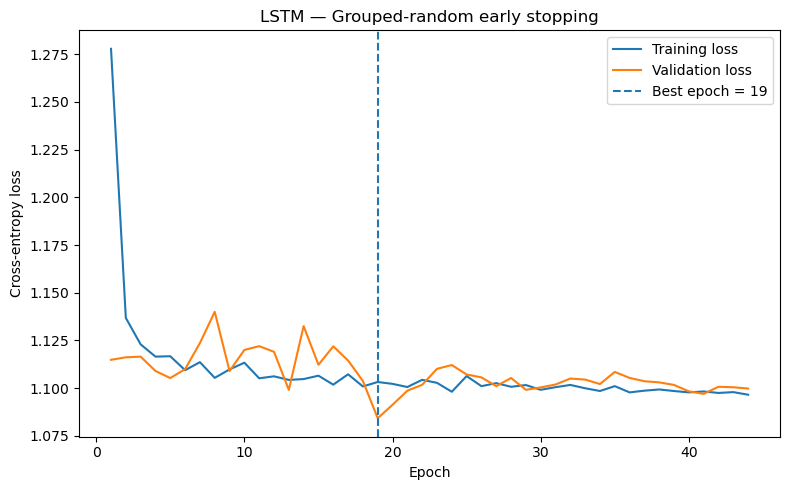

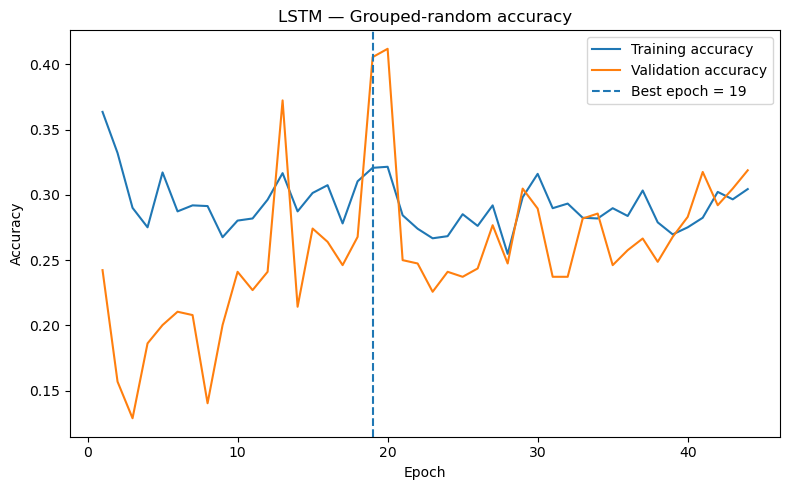

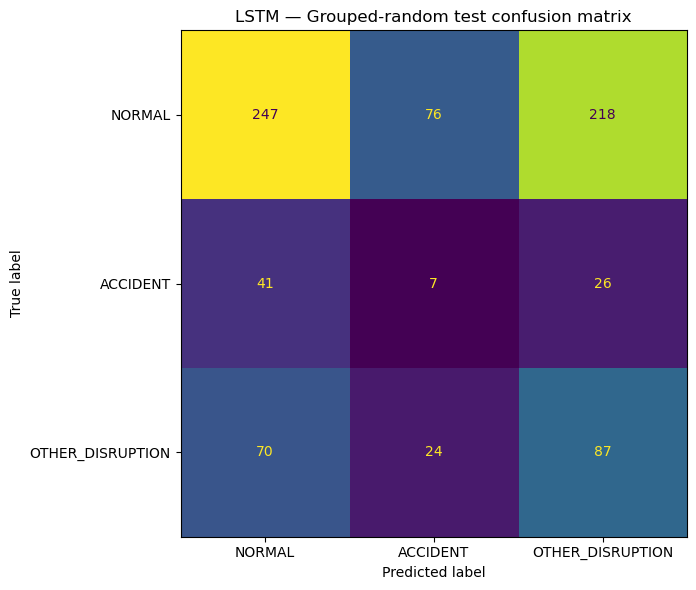

In [7]:

grouped_results = run_lstm_experiment(
    split_name="Grouped-random",
    manifest=grouped_manifest,
)


## 6. Spatial holdout experiment


=== Spatial holdout ===
Train / validation / test: 3703 806 756
Class weights: {0: 0.49039862269898027, 1: 3.5571565802113354, 2: 1.4711958680969408}


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2517,347,839
validation,549,84,173
test,515,74,167


01/3 | epochs= 30 | best_epoch=  5 | val_macro_f1=0.3287 | val_loss=1.0753
02/3 | epochs= 63 | best_epoch= 38 | val_macro_f1=0.2876 | val_loss=1.0966
03/3 | epochs=112 | best_epoch= 87 | val_macro_f1=0.1664 | val_loss=1.1179

Best validation configuration:
{'lstm_units': 32, 'dense_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'learning_rate': 0.001, 'l2_strength': 0.0001}


,lstm_units,dense_units,dropout,recurrent_dropout,learning_rate,l2_strength,epochs_trained,best_epoch,best_validation_loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,32,16,0.3,0.1,0.0010,0.0001,30,5,1.075276,0.451613,0.335488,0.328698,0.475904
1,64,32,0.4,0.1,0.0010,0.0001,63,38,1.096558,0.348635,0.354131,0.287598,0.388967
2,32,16,0.5,0.2,0.0005,0.0010,112,87,1.117949,0.160050,0.349083,0.166428,0.105577



Overall metrics:


,split_scheme,partition,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Spatial holdout,train,5,0.439103,0.343233,0.330191,0.470965
1,Spatial holdout,validation,5,0.451613,0.335488,0.328698,0.475904
2,Spatial holdout,test,5,0.501323,0.334566,0.332148,0.506700



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.675351,0.654369,0.664694,515.000000
ACCIDENT,0.142857,0.175676,0.157576,74.000000
OTHER_DISRUPTION,0.174699,0.173653,0.174174,167.000000
accuracy,0.501323,0.501323,0.501323,0.501323
macro avg,0.330969,0.334566,0.332148,756.000000
weighted avg,0.512635,0.501323,0.506700,756.000000


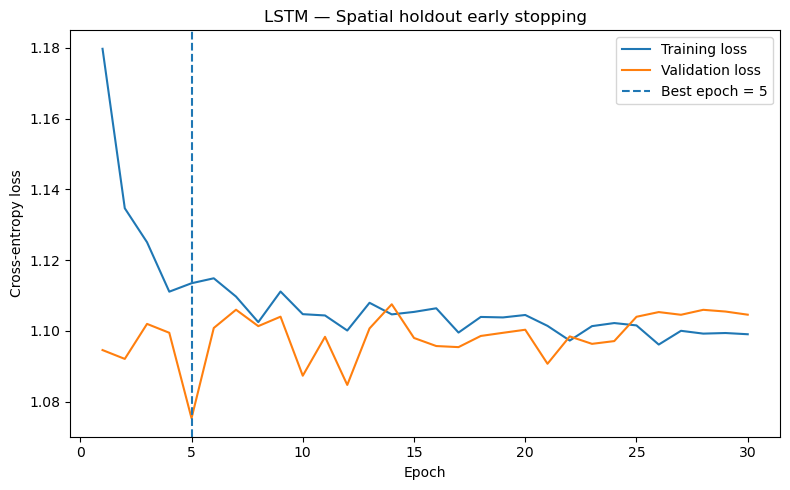

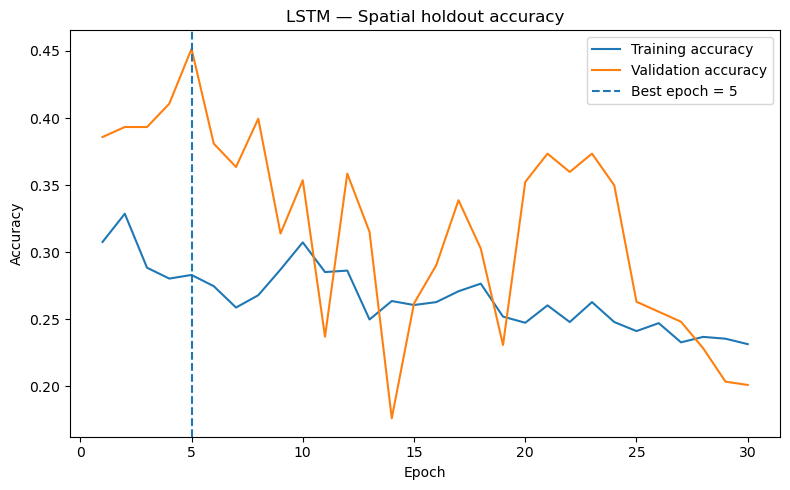

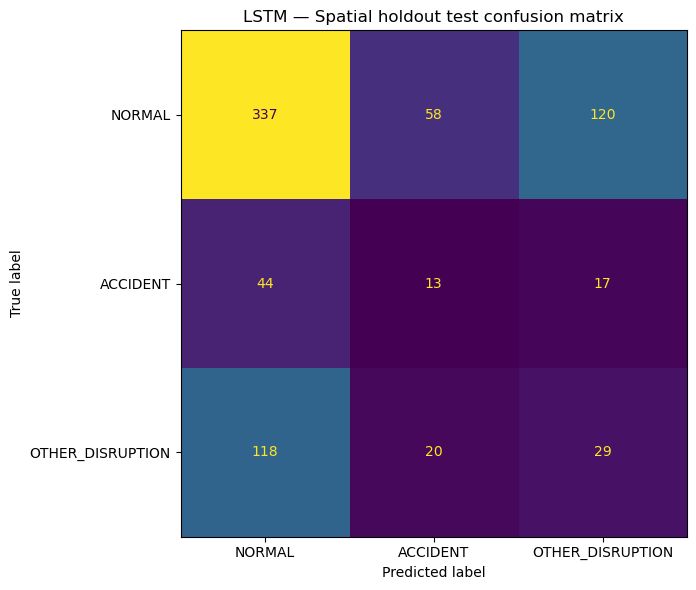

In [8]:

spatial_results = run_lstm_experiment(
    split_name="Spatial holdout",
    manifest=spatial_manifest,
)


## 7. Final comparison

In [9]:

comparison = pd.concat(
    [grouped_results["metrics"], spatial_results["metrics"]],
    ignore_index=True,
)

comparison.to_csv(
    OUTPUT_DIR / "lstm_all_metrics.csv",
    index=False,
)

test_comparison = comparison[
    comparison["partition"].eq("test")
].reset_index(drop=True)

print("LSTM test-set comparison:")
display(test_comparison)

print("\nReference baselines:")
print("Decision Tree grouped/spatial Macro-F1: 0.303 / 0.253")
print("Random Forest grouped/spatial Macro-F1: 0.352 / 0.313")
print("XGBoost grouped/spatial Macro-F1: 0.336 / 0.287")

print("\nSaved files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print("-", p.name)


LSTM test-set comparison:


,split_scheme,partition,best_epoch,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,test,19,0.428392,0.343940,0.322230,0.457933
1,Spatial holdout,test,5,0.501323,0.334566,0.332148,0.506700



Reference baselines:
Decision Tree grouped/spatial Macro-F1: 0.303 / 0.253
Random Forest grouped/spatial Macro-F1: 0.352 / 0.313
XGBoost grouped/spatial Macro-F1: 0.336 / 0.287

Saved files:
- grouped_random_accuracy_curve.png
- grouped_random_best_config.json
- grouped_random_configuration_search.csv
- grouped_random_confusion_matrix.png
- grouped_random_early_stopping_curve.png
- grouped_random_lstm_model.keras
- grouped_random_metrics.csv
- grouped_random_predictions.csv
- grouped_random_scaler.npz
- grouped_random_test_classification_report.csv
- grouped_random_training_history.csv
- lstm_all_metrics.csv
- spatial_holdout_accuracy_curve.png
- spatial_holdout_best_config.json
- spatial_holdout_configuration_search.csv
- spatial_holdout_confusion_matrix.png
- spatial_holdout_early_stopping_curve.png
- spatial_holdout_lstm_model.keras
- spatial_holdout_metrics.csv
- spatial_holdout_predictions.csv
- spatial_holdout_scaler.npz
- spatial_holdout_test_classification_report.csv
- spatial


## Interpretation guidance

Focus on:

- test Macro-F1;
- `ACCIDENT` recall and F1;
- grouped-random versus spatial holdout;
- training versus validation Macro-F1;
- the best epoch selected by early stopping;
- whether validation loss begins increasing while training loss continues decreasing;
- whether LSTM exceeds the current Random Forest results:
  - grouped-random Macro-F1: **0.352**
  - spatial holdout Macro-F1: **0.313**

Early stopping uses validation loss and restores the best weights.  
The validation set is used for model selection, while the test set is not used during training or tuning.
